# 최종 확인 노트북

과제 실습과 직접 만든 틀린그림찾기를 **한 노트북에 모은 최종 확인용 노트북**이다.

| 부 | 내용 | 원래 노트북 |
|---|---|---|
| 1부. YOLOv8 제조 데이터 객체 탐지 실습 — 직접 해보기 | 과제 원본 코드(버스 이미지 추론, stamp 데이터 학습·평가)를 11개 흐름으로 나눠 직접 실행하고, 흐름마다 이해한 내용을 **✍️ 내 코멘트** 칸에 직접 적었다. 흐름 8 뒤에는 **🔬 개인 실험 1**(신뢰도 임계값, 추가 샘플 zidane으로 모델 비교, IoU·NMS)을 넣었다 | `notebooks/실습_직접해보기.ipynb` |
| 2부. YOLO로 틀린그림찾기 | Gemini로 문제 그림 5장을 만들고, YOLO로 두 그림의 물체를 찾아 비교하는 탐지기를 만들어 채점했다 (재현율 65.7%, 정밀도 100%) | `spotdiff/spotdiff_yolo.ipynb` |

각 부의 실행 결과는 원래 노트북을 실행한 결과를 그대로 옮긴 것이다. 1부는 학습이 들어 있어 처음부터 다시 실행하면 시간이 걸린다.
각 부 앞의 작업 폴더 이동 칸은 이 노트북을 레포 맨 위에서 다시 실행할 때를 위한 것이다.
틀린그림찾기를 만들며 겪은 시행착오는 `spotdiff/report/작업기록.md`에 따로 정리했다.
개인 회고(막혔던 부분과 해결, KPT, AAR)와 실습 전체 정리는 맨 끝에 한 번에 적었다.


# 1부. YOLOv8 제조 데이터 객체 탐지 실습 — 직접 해보기

과제 원본 코드를 **흐름 단위로 묶어** 놓았다. 한 흐름을 끝까지 실행한 뒤, 그 아래 코멘트 칸에 무엇을 했고 무엇을 알게 됐는지 적는다.

**실행 전 확인**
- 오른쪽 위 커널이 **CV-YOLO (.venv)** 인지 확인한다.
- 데이터셋은 `CV-YOLO/datasets/stamp/` 에 있어서 과제 코드의 `../datasets/stamp/...` 경로가 그대로 맞는다.
- 실행 결과는 `CV-YOLO/notebooks/runs/` 아래에 저장된다.
- 학습(흐름 9)은 GPU로 약 3~4분 걸린다.

In [ ]:
# 이 부의 코드는 notebooks/ 폴더 기준 경로를 쓴다
import os
from pathlib import Path
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'spotdiff').is_dir())   # 레포 맨 위
os.chdir(REPO / 'notebooks')

In [3]:
import torch, ultralytics
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__, "| GPU 사용 가능:", torch.cuda.is_available())

ultralytics 8.4.154 | torch 2.11.0+cu128 | GPU 사용 가능: True


## 흐름 1. 설치하고 모델 불러오기
패키지를 설치하고 COCO로 사전학습된 `yolov8n.pt` 를 불러온다.

In [4]:
!pip install ultralytics


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from ultralytics import YOLO

In [6]:
model = YOLO('yolov8n.pt')

> ✍️ **내 코멘트**
>
>

## 흐름 2. 예제 이미지 준비
버스 사진을 인터넷에서 받아 화면에 띄운다.

In [7]:
example_imgs = ['https://ultralytics.com/images/bus.jpg']

In [8]:
from PIL import Image
import requests
from io import BytesIO

In [9]:
response = requests.get(example_imgs[0])
img = Image.open(BytesIO(response.content))

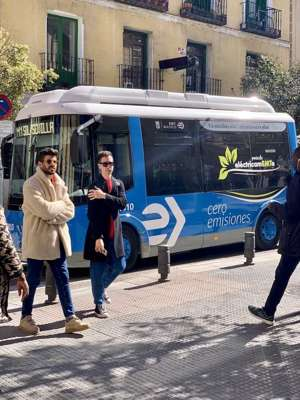

In [10]:
img.thumbnail((400,400))
img

> ✍️ **내 코멘트**
>사전에 준비된 데이터를 400*400 사이즈 상자안에 깨지지 않게 보이게 하는 것을 알았다.

## 흐름 3. 추론 실행하고 결과 이미지 보기
사진 한 장을 모델에 넣고, 박스가 그려져 저장된 이미지를 확인한다.

In [11]:
results = model.predict(example_imgs[0], save=True, conf=0.25)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 12.6ms
Speed: 90.8ms preprocess, 12.6ms inference, 43.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\runs\detect\predict-2


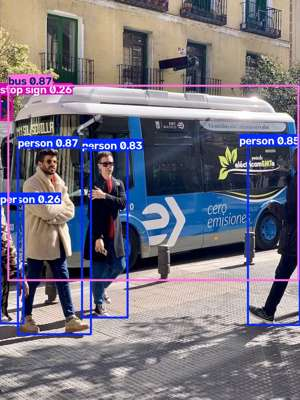

In [12]:
# 여러 번 실행하면 predict2, predict3…으로 폴더가 바뀌므로 실제 저장된 폴더를 쓴다
output_img = Image.open(f'{results[0].save_dir}/bus.jpg')
output_img.thumbnail((400,400))
output_img

> ✍️ **내 코멘트**
>신뢰도 25%이상인 물체에 박스를 치는 작업을 했고 이후 저장하라는 흐름이였다
>

## 흐름 4. 결과 구조 살펴보기
`results` 안에 무엇이 들어 있는지, 클래스 번호와 이름은 어떻게 이어지는지 본다.

In [13]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

In [14]:
type(results)

list

In [15]:
type(results[0])

ultralytics.engine.results.Results

In [16]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')
data: tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
    

In [17]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

In [18]:
import yaml
import requests

url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

response = requests.get(url)
data = yaml.safe_load(response.text)

print(data)

{'path': 'coco', 'train': 'train2017.txt', 'val': 'val2017.txt', 'test': 'test-dev2017.txt', 'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toi

In [19]:
results[0].boxes.conf

tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')

In [20]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8732, 0.8657, 0.8528, 0.8253, 0.2608, 0.2552], device='cuda:0')
data: tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
    

> ✍️ **내 코멘트**
>xywh은 중심점과 크기를 나타내고 xyxy는 각 사각형의 꼭짓점 좌표를 나타내는것을 알앗고 두개 끝에 n은 정규화임을 알았다. cls는 어떤 클래스로 판단했는지 conf는 어느정도 확신하는지, data는 [x_1, y_1, x_2, y_2, conf, cls]임을 알았다.
>

## 흐름 5. 좌표 형식 확인하기
`xywh`·`xyxy` 픽셀 좌표를 원본 크기로 직접 나눠 보고, `n` 이 붙은 정규화 좌표와 비교한다.

In [21]:
img.size

(300, 400)

In [22]:
results[0].boxes.xywh

tensor([[413.9292, 494.0699, 782.1526, 525.5790],
        [146.9449, 650.6298, 196.7977, 504.1556],
        [739.5948, 634.6099, 140.2510, 484.8480],
        [283.2428, 631.6757, 123.4565, 451.7523],
        [ 31.5197, 711.9839,  63.0394, 322.9200],
        [ 16.3075, 289.6674,  32.4993,  70.4186]], device='cuda:0')

In [23]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

In [24]:
import cv2
import requests
import numpy as np
from PIL import Image
from io import BytesIO

img_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)
height, width = img_np.shape[:2]

In [25]:
height, width

(1080, 810)

In [26]:
bbox1 = results[0].boxes.xywh[0]
bbox1

tensor([413.9292, 494.0699, 782.1526, 525.5790], device='cuda:0')

In [27]:
bbox1[0]/width, bbox1[1]/height, bbox1[2]/width, bbox1[3]/height

(tensor(0.5110, device='cuda:0'),
 tensor(0.4575, device='cuda:0'),
 tensor(0.9656, device='cuda:0'),
 tensor(0.4866, device='cuda:0'))

In [28]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

In [29]:
bbox2 = results[0].boxes.xyxy[0]
bbox2

tensor([ 22.8529, 231.2805, 805.0055, 756.8594], device='cuda:0')

In [30]:
bbox2[0]/width, bbox2[1]/height, bbox2[2]/width, bbox2[3]/height

(tensor(0.0282, device='cuda:0'),
 tensor(0.2141, device='cuda:0'),
 tensor(0.9938, device='cuda:0'),
 tensor(0.7008, device='cuda:0'))

In [31]:
results[0].boxes.xyxyn[0]

tensor([0.0282, 0.2141, 0.9938, 0.7008], device='cuda:0')

> ✍️ **내 코멘트**
> 직접 해본결과 같음을 알 수 있다. (30줄과 31줄)

## 흐름 6. 박스 직접 그리기
좌표를 꺼내 OpenCV로 사각형을 그리고 matplotlib으로 띄운다.

In [32]:
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(BytesIO(response.content)).convert("RGB"))
h, w = img.shape[:2]
img_copy = img.copy()

In [33]:
xyxy_coordinate = results[0].boxes.xyxy.cpu().numpy()

In [34]:
xyxy_coordinate

array([[     22.853,      231.28,      805.01,      756.86],
       [     48.546,      398.55,      245.34,      902.71],
       [     669.47,      392.19,      809.72,      877.03],
       [     221.51,       405.8,      344.97,      857.55],
       [          0,      550.52,      63.039,      873.44],
       [   0.057797,      254.46,      32.557,      324.88]], dtype=float32)

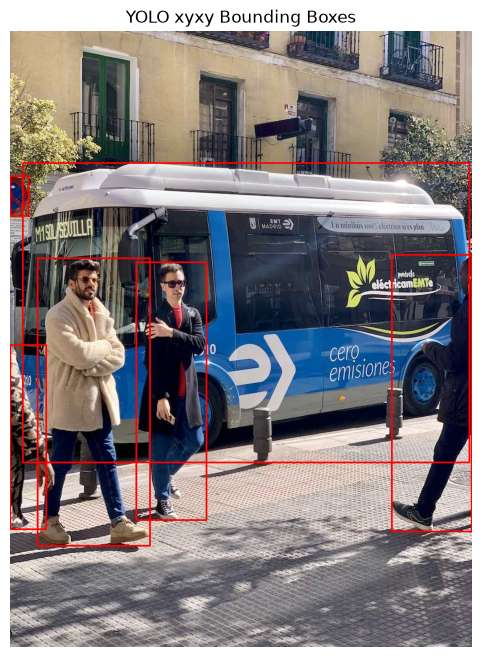

In [35]:
import matplotlib.pyplot as plt

for box in xyxy_coordinate:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("YOLO xyxy Bounding Boxes")
plt.axis("off")
plt.show()

> ✍️ **내 코멘트**
>이전에 학습했던 모델의 xy좌표를 활용해서 박스를 치고 있다
>

## 흐름 7. 필요한 클래스만 골라 그리기
`boxes.data` 를 풀어서 사람(class 0)만 이름·신뢰도와 함께 표시한다.

In [36]:
results[0].boxes.data

tensor([[2.2853e+01, 2.3128e+02, 8.0501e+02, 7.5686e+02, 8.7323e-01, 5.0000e+00],
        [4.8546e+01, 3.9855e+02, 2.4534e+02, 9.0271e+02, 8.6572e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7703e+02, 8.5275e-01, 0.0000e+00],
        [2.2151e+02, 4.0580e+02, 3.4497e+02, 8.5755e+02, 8.2528e-01, 0.0000e+00],
        [0.0000e+00, 5.5052e+02, 6.3039e+01, 8.7344e+02, 2.6076e-01, 0.0000e+00],
        [5.7797e-02, 2.5446e+02, 3.2557e+01, 3.2488e+02, 2.5521e-01, 1.1000e+01]], device='cuda:0')

In [37]:
det = results[0].boxes.data.cpu().numpy()

In [38]:
type(det)

numpy.ndarray

In [39]:
type(det)

numpy.ndarray

In [40]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

# URL에서 YAML 텍스트 불러오기
response = requests.get(url)
yaml_content = response.text

# YAML 파싱
parsed = yaml.safe_load(yaml_content)

# 클래스 이름 추출
class_names = parsed['names']

In [41]:
class_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

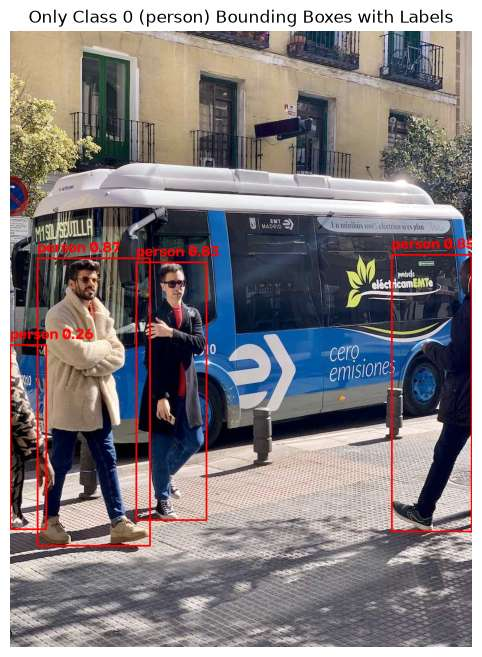

In [42]:
img_copy = img_np.copy()


for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == 0:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        label = f"{class_names[int(cls)]} {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 0, 0), 2)


plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("Only Class 0 (person) Bounding Boxes with Labels")
plt.axis("off")
plt.show()

> ✍️ **내 코멘트**
>클래스 이름을 확인하고 클래스가 person인 경우만 true처리해 사람만 박스치고 있다
>

## 흐름 8. 탐지 영역 잘라내기
버스 박스 영역만 잘라 파일로 저장하고 다시 읽어 확인한다.

In [43]:
import os
bus_class_id = [k for k, v in class_names.items() if v == 'bus'][0]
os.makedirs("bus_crops", exist_ok=True)

count = 0
for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == bus_class_id:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cropped = img_np[y1:y2, x1:x2]
        save_path = f"bus_crops/bus_crop_{count}.jpg"
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
        print(f"버스 {count}번 잘라서 저장: {save_path}")
        count += 1

버스 0번 잘라서 저장: bus_crops/bus_crop_0.jpg


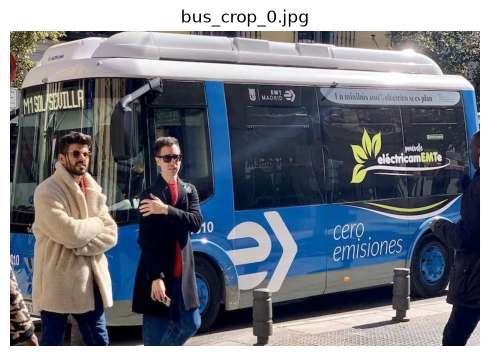

In [44]:
import os
import cv2
import matplotlib.pyplot as plt

crop_folder = "bus_crops"

image_files = sorted([f for f in os.listdir(crop_folder) if f.endswith(".jpg")])

num_images = len(image_files)
plt.figure(figsize=(5 * num_images, 5))

for i, filename in enumerate(image_files):
    img_path = os.path.join(crop_folder, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR로 불러오기 때문에 RGB로 변환

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

> ✍️ **내 코멘트**
>원본사진에서 버스 박스부분만 따로 빼서 보여주고 있다
>

---
## 🔬 개인 실험 1 — 사전학습 모델을 더 알아보기

기본 실습에서 생긴 질문을 직접 확인한다.
1. **신뢰도 임계값(conf)** 을 바꾸면 탐지 결과가 어떻게 달라지나?
2. **추가 샘플 이미지**에서도 잘 되나? **모델 크기·버전**(YOLOv8n / YOLOv8s / YOLO11n)에 따라 무엇이 달라지나?
3. **NMS의 IoU 임계값**은 겹친 박스에 어떤 영향을 주나?

**용어 정리**
| 용어 | 뜻 |
|---|---|
| **신뢰도(conf)** | 모델이 "여기에 이 물체가 있다"고 확신하는 정도(0~1). 기준값보다 낮은 박스는 버린다. |
| **모델 크기** | `n`(nano) < `s`(small) < `m` < `l` < `x`. 클수록 파라미터가 많아 정확할 수 있지만 느리다. |
| **모델 버전** | YOLOv8 → YOLO11처럼 숫자가 클수록 최신 구조다. |
| **IoU** | 두 박스가 얼마나 겹치는지(0~1). 완전히 겹치면 1, 안 겹치면 0. |
| **NMS** | 물체 하나에 겹쳐 나온 박스 중 **하나만 남기는** 정리 단계. IoU가 기준값보다 큰 박스를 중복으로 보고 지운다. (자세한 과정은 1-3) |

모델 비교는 공정하게 **같은 조건끼리** 한다. **버전 효과는 v8n vs 11n**(둘 다 nano), **크기 효과는 v8n vs v8s**(둘 다 v8)로 본다.

In [42]:
import pandas as pd
import torch
from pathlib import Path

DEVICE = 0 if torch.cuda.is_available() else "cpu"
bus_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

rows = []
for c in [0.05, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85]:
    r = model.predict(bus_bgr, conf=c, device=DEVICE, verbose=False)[0]
    names = [class_names[int(k)] for k in r.boxes.cls]
    rows.append({"conf": c, "boxes": len(names), "person": names.count("person"),
                 "bus": names.count("bus"), "others": ", ".join(n for n in names if n not in ("person", "bus")) or "-"})
pd.DataFrame(rows)

,conf,boxes,person,bus,others
0,0.05,13,5,3,"stop sign, skateboard, bicycle, handbag, handbag"
1,0.10,6,4,1,stop sign
2,0.25,6,4,1,stop sign
3,0.40,4,3,1,-
4,0.55,4,3,1,-
5,0.70,4,3,1,-
6,0.85,3,2,1,-


**실험 1-1 결과 해석**

- **0.05**: 박스가 13개로 늘었다. 사람 5명, 버스 3개(같은 버스에 박스가 겹쳐 나옴)에 skateboard·bicycle·handbag 같은 **없는 물체(오탐)** 가 섞였다.
- **0.10~0.25**: 6개(버스 1, 사람 4, 정지 표지판 1)로 안정적이다. 과제 기본값 0.25가 무난한 이유다.
- **0.40~0.70**: 4개. 신뢰도 0.26짜리였던 **왼쪽 끝의 잘린 사람**과 **정지 표지판**이 빠진다.
- **0.85**: 3개. 확실한 사람 한 명(0.83)까지 빠진다.

→ 임계값은 **놓침(미탐)과 헛것(오탐) 사이의 조절 손잡이**다. 제조 검사처럼 놓치면 안 되는 상황에서는 낮게, 오탐 비용이 크면 높게 잡아야 한다.

In [43]:
SAMPLES = {"bus": "https://ultralytics.com/images/bus.jpg",
           "zidane": "https://ultralytics.com/images/zidane.jpg"}
MODELS = ["yolov8n.pt", "yolov8s.pt", "yolo11n.pt"]

samples = {k: cv2.imdecode(np.frombuffer(requests.get(u).content, np.uint8), cv2.IMREAD_COLOR) for k, u in SAMPLES.items()}
rows, vis = [], {}
for mname in MODELS:
    m = YOLO(mname)
    for sname, im in samples.items():
        m.predict(im, device=DEVICE, verbose=False)            # 첫 호출(워밍업)은 시간 측정에서 제외
        r = m.predict(im, conf=0.25, device=DEVICE, verbose=False)[0]
        names = [r.names[int(k)] for k in r.boxes.cls]
        rows.append({"model": mname, "image": sname, "boxes": len(names),
                     "detected": ", ".join(f"{n}×{names.count(n)}" for n in sorted(set(names))),
                     "mean_conf": round(float(r.boxes.conf.mean()), 3) if len(names) else 0,
                     "infer_ms": round(r.speed["inference"], 1),
                     "params(M)": round(sum(p.numel() for p in m.model.parameters()) / 1e6, 1)})
        vis[(mname, sname)] = r.plot()[:, :, ::-1]
model_cmp = pd.DataFrame(rows)
model_cmp

,model,image,boxes,detected,mean_conf,infer_ms,params(M)
0,yolov8n.pt,bus,6,"bus×1, person×4, stop sign×1",0.655,10.3,3.2
1,yolov8n.pt,zidane,3,"person×2, tie×1",0.649,13.4,3.2
2,yolov8s.pt,bus,5,"bus×1, person×4",0.838,14.6,11.2
3,yolov8s.pt,zidane,3,"person×2, tie×1",0.830,11.6,11.2
4,yolo11n.pt,bus,5,"bus×1, person×4",0.837,14.6,2.6
5,yolo11n.pt,zidane,3,"person×2, tie×1",0.691,11.2,2.6


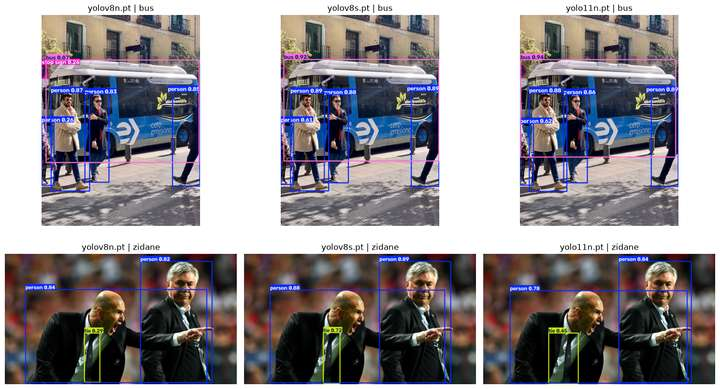

In [44]:
fig, axes = plt.subplots(len(SAMPLES), len(MODELS), figsize=(5 * len(MODELS), 4.5 * len(SAMPLES)))
for i, sname in enumerate(SAMPLES):
    for j, mname in enumerate(MODELS):
        axes[i, j].imshow(vis[(mname, sname)]); axes[i, j].set_title(f"{mname} | {sname}"); axes[i, j].axis("off")
plt.tight_layout(); plt.show()

**실험 1-2 결과 해석**

세 모델을 **같은 조건끼리 두 쌍으로** 비교한다.

| 비교 | 같은 것 | 바뀐 것 | 버스 사진 평균 신뢰도 | zidane 사진 (넥타이 / 평균) |
|---|---|---|---|---|
| v8n → **11n** | 크기 (둘 다 nano) | 버전 | 0.66 → 0.84 | 0.29 → 0.45 / 0.65 → 0.69 |
| v8n → **v8s** | 버전 (둘 다 v8) | 크기 | 0.66 → 0.84 | 0.29 → 0.72 / 0.65 → 0.83 |

- **버전 효과 (nano끼리):** 11n이 v8n보다 더 확신 있게 예측했다. 파라미터도 2.6M으로 v8n(3.2M)보다 작다. 다만 zidane에서는 사람 한 명(0.78)이 v8n(0.82)보다 조금 낮았다.
- **크기 효과 (v8끼리):** v8s가 가장 확신 있게 예측했지만, 파라미터는 v8n의 약 3.5배(11.2M)다.
- **찾은 물체는 거의 같다.** zidane에서는 세 모델 모두 사람 2 + 넥타이 1을 찾았고, 버스 사진에서는 신뢰도 0.26이던 정지 표지판을 v8n만 잡았다. 그래서 이 차이는 **정확도보다는 확신 정도의 차이**다.
- 한 장씩 추론한 시간(10~18ms)은 GPU 준비 시간의 영향이 커서, 이 실험만으로 속도 차이를 말하기는 어렵다.

In [45]:
rows = []
for iou in [0.3, 0.5, 0.7, 0.9]:
    for sname, im in samples.items():
        r = model.predict(im, conf=0.1, iou=iou, device=DEVICE, verbose=False)[0]
        rows.append({"iou(NMS)": iou, "image": sname, "boxes": len(r.boxes)})
pd.DataFrame(rows).pivot(index="iou(NMS)", columns="image", values="boxes")

image,bus,zidane
iou(NMS),,
0.3,6,6
0.5,6,8
0.7,6,12
0.9,9,13


**IoU(Intersection over Union)란?** 두 박스가 **얼마나 겹치는지**를 0~1로 나타낸 값이다.
IoU = **겹친 넓이 ÷ 두 박스를 합친 넓이**. 완전히 겹치면 1, 전혀 안 겹치면 0이다.

**NMS(Non-Maximum Suppression, 중복 박스 제거)란?** YOLO는 물체 하나에 박스를 여러 개 겹쳐서 예측한다. NMS는 그중 **하나만 남기는 정리 단계**다.
1. 신뢰도가 가장 높은 박스를 고른다.
2. 그 박스와 **IoU가 기준값(`iou`)보다 큰** 박스는 같은 물체를 중복으로 잡은 것으로 보고 지운다.
3. 남은 박스들로 1~2를 반복한다.

→ `iou` 기준을 **낮추면** 조금만 겹쳐도 지워서 박스가 **적어지고**, **높이면** 많이 겹쳐야 지워서 박스가 **많아진다**.

**실험 1-3 결과 해석**

- **버스 사진**은 IoU 0.3~0.7에서 6개로 그대로였고, 0.9에서야 9개로 늘었다. 사람들이 서로 많이 겹치지 않아서다.
- **zidane 사진**은 0.3 → 6개, 0.5 → 8개, 0.7 → 12개, 0.9 → 13개로 크게 변했다. 같은 사람에게 여러 박스가 겹쳐 나오는데, IoU 기준이 느슨할수록 그 중복 박스가 지워지지 않고 남는다.

→ 제품이 **촘촘히 붙어 있는 라인**에서는 IoU를 너무 낮추면 붙은 제품 두 개가 하나로 합쳐지고, 너무 높이면 한 제품에 박스가 여러 개 생긴다. 기본값 0.7 근처에서 현장 배치에 맞게 조정해야 한다.

## 흐름 9. 학습 준비와 파인튜닝
새 사전학습 모델을 불러와 stamp 데이터로 20 에폭 학습한다. GPU로 3~4분 걸린다.

In [45]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")

In [46]:
model.train(
    data="../datasets/stamp/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    name="stamp_detect",
    device=0
)

New https://pypi.org/project/ultralytics/8.4.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.154  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../datasets/stamp/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002D403AE2390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

✍️ 내 코멘트
- Precision (정밀도): 모델이 "맞다"고 예측한 것들 중, 실제로 맞춘 비율
- Recall (재현율): 실제로 존재하는 전체 정답들 중, 모델이 놓치지 않고 찾아낸 비율
- mAP50: 박스를 조금 널널하게 맞춰도(50% 이상만 겹치면) "객체를 잘 찾았는가"에 초점을 맞춘 종합 정확도 점수
- mAP50-95: 박스 위치를 얼마나 정밀하게 그렸는지(50%부터 95% 겹침까지 단계별로 평가) "박스 위치의 완벽도"까지 엄격하게 반영한 종합 정확도 점수
- 결과를 보면 신발하고 도장이 클라스인걸 알 수 있다

## 흐름 10. 평가하기
검증 데이터로 채점하고, 지표를 표로 정리한다.

In [47]:
metrics = model.val()
print("🔍 평가 결과:", metrics)

Ultralytics 8.4.154  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 117.325.2 MB/s, size: 26.6 KB)
val: Scanning C:\Users\LOQ5060\Desktop\CV-YOLO\datasets\stamp\valid\labels.cache... 273 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.8it/s 3.1s0.1s
                   all        273        952      0.953      0.987      0.985       0.64
                 shoes        204        408      0.928      0.974      0.975      0.717
                 stamp        273        544      0.978          1      0.995      0.562
Speed: 1.6ms preprocess, 2.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\runs\detect\val-2
🔍 평가 결과: ultralytics.u

In [48]:
import pandas as pd

data = {
    "Class": ["all", "shoes", "stamp"],
    "Images": [273, 204, 273],
    "Instances": [952, 408, 544],
    "Precision": [0.953, 0.928, 0.978],
    "Recall": [0.987, 0.974, 1.000],
    "mAP@.5": [0.985, 0.975, 0.995],
    "mAP@.5:.95": [0.640, 0.717, 0.562],
}

df = pd.DataFrame(data)

print("### 📊 Evaluation Results Table (Markdown Format)\n")
print(df.to_markdown(index=False))

print("\n### 📝 Explanation of Each Column")
print("""
- **Class**: Object class name. "all" means aggregated results over all classes.
- **Images**: Number of images in which this class appears (or total evaluation images for 'all').
- **Instances**: Total number of ground truth objects for the class.
- **Precision**: Proportion of correct positive predictions (TP / (TP + FP)).
- **Recall**: Proportion of ground truths that were correctly detected (TP / (TP + FN)).
- **mAP@.5**: Mean Average Precision at IoU threshold 0.5.
- **mAP@.5:.95**: mAP averaged over IoU thresholds from 0.5 to 0.95 in steps of 0.05 (more stringent metric).
""")

### 📊 Evaluation Results Table (Markdown Format)

| Class   |   Images |   Instances |   Precision |   Recall |   mAP@.5 |   mAP@.5:.95 |
|:--------|---------:|------------:|------------:|---------:|---------:|-------------:|
| all     |      273 |         952 |       0.953 |    0.987 |    0.985 |        0.64  |
| shoes   |      204 |         408 |       0.928 |    0.974 |    0.975 |        0.717 |
| stamp   |      273 |         544 |       0.978 |    1     |    0.995 |        0.562 |

### 📝 Explanation of Each Column

- **Class**: Object class name. "all" means aggregated results over all classes.
- **Images**: Number of images in which this class appears (or total evaluation images for 'all').
- **Instances**: Total number of ground truth objects for the class.
- **Precision**: Proportion of correct positive predictions (TP / (TP + FP)).
- **Recall**: Proportion of ground truths that were correctly detected (TP / (TP + FN)).
- **mAP@.5**: Mean Average Precision at IoU threshold 0.5.


In [49]:
metrics.box.map, metrics.box.map50, metrics.box.map75, metrics.box.maps

(np.float64(0.6395495664152615),
 np.float64(0.9850004041920235),
 np.float64(0.7395406571714536),
 array([    0.71673,     0.56237]))

> ✍️ **내 코멘트**
>표로 정리해 한눈에 결과를 파악하기 쉬웠다 도장을 신발보다 더 잘 찾아내지만 박스 정확도는 도장보다 신발이 더 높음을 알 수 있다

## 흐름 11. test 이미지로 예측해 보기
학습에 쓰지 않은 사진으로 예측하고 결과 박스를 확인한다.

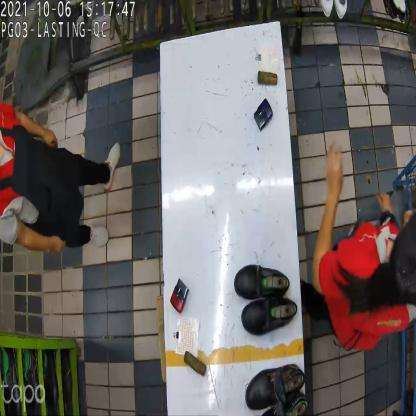

In [50]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')

image

In [51]:
results = model.predict('../datasets/stamp/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg')
results[0].save(filename='predicted1.jpg')


image 1/1 C:\Users\LOQ5060\Desktop\CV-YOLO\notebooks\..\datasets\stamp\test\images\clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg: 640x640 2 shoess, 2 stamps, 14.1ms
Speed: 3.2ms preprocess, 14.1ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


'predicted1.jpg'

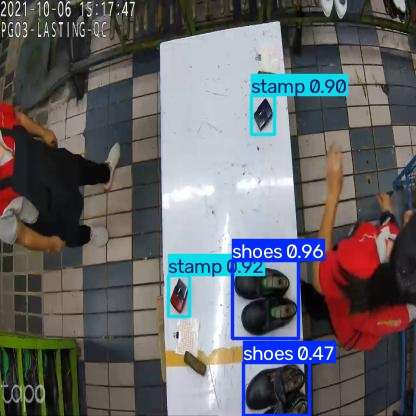

In [52]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("predicted1.jpg")

image

In [53]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1., 1., 0.], device='cuda:0')
conf: tensor([0.9577, 0.9223, 0.8993, 0.4741], device='cuda:0')
data: tensor([[232.5940, 260.6025, 298.7854, 338.3451,   0.9577,   0.0000],
        [168.5933, 275.5515, 189.8084, 316.0340,   0.9223,   1.0000],
        [251.9562,  95.4230, 274.1241, 134.1069,   0.8993,   1.0000],
        [243.2766, 362.1186, 309.7711, 415.9079,   0.4741,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (416, 416)
shape: torch.Size([4, 6])
xywh: tensor([[265.6897, 299.4738,  66.1914,  77.7425],
        [179.2008, 295.7927,  21.2151,  40.4825],
        [263.0402, 114.7650,  22.1678,  38.6839],
        [276.5239, 389.0132,  66.4945,  53.7892]], device='cuda:0')
xywhn: tensor([[0.6387, 0.7199, 0.1591, 0.1869],
        [0.4308, 0.7110, 0.0510, 0.0973],
        [0.6323, 0.2759, 0.0533, 0.0930],
        [0.6647, 0.9351, 0.1598, 0.1293]], device='cuda:0')
xyxy: tensor([[232.5940, 260.6025, 2

✍️ 내 코멘트
탐지된 모든 객체의 상세 정보(cls, conf, 좌표 등)를 직관적으로 확인할 수 있었다. 상단 및 중앙의 객체들은 90% 이상의 높은 신뢰도로 탐지된 반면, 하단의 신발은 47.4%의 다소 낮은 신뢰도로 관측되었다.

원인을 추론해 보면, 하단 신발은 이미지 테두리 부분에서 일부가 잘려서(Crop) 특성이 완벽하게 드러나지 않았기 때문으로 보인다. 마찬가지로 실시간 모니터링 환경에서도 손이나 다른 물체가 대상 객체를 가릴 경우(Occlusion) 신뢰도가 낮게 나올 수 있음을 유추해 볼 수 있다.

# 2부. YOLO로 틀린그림찾기

두 그림에서 다른 곳을 YOLO로 찾아 표시하고, 정답과 비교해 점수를 매긴다.
아이디어는 간단하다. YOLO로 두 그림의 물체를 전부 박스로 찾은 뒤, 박스끼리 비교한다.

여기까지 오는 과정(도안에서는 YOLO가 아무것도 못 찾음, 직접 편집한 데이터는 부자연스러움, 그래서 Gemini로 문제를 만듦)은
[report/작업기록.md](spotdiff/report/작업기록.md)에 정리했다. 이 노트북은 **데이터를 확인하고 탐지기를 만들어 채점하는 과정**을 순서대로 실행한다.

| 순서 | 내용 |
|---|---|
| 1 | 준비 |
| 2 | 데이터 보기 — Gemini로 만든 5문제 |
| 3 | YOLO가 이 그림을 알아볼까? |
| 4 | 박스 짝짓기 |
| 5 | 후보 자리의 내용 비교 |
| 6 | 한 문제 풀어 보기 |
| 7 | 5문제 채점 |
| 8 | 놓친 것과 한계 |

In [ ]:
# 이 부의 코드는 spotdiff/ 폴더 기준 경로를 쓴다
import os
from pathlib import Path
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'spotdiff').is_dir())   # 레포 맨 위
os.chdir(REPO / 'spotdiff')

## 1. 준비

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.rcParams["font.family"] = "Malgun Gothic"      # 한글 제목
ROOT = Path.cwd()                                   # spotdiff 폴더에서 실행
sys.path.insert(0, str(ROOT / "src"))
import detect_diff as dd                            # 탐지기 코드 (src/detect_diff.py)

DS = ROOT / "dataset_ai"
answers = {k: v for k, v in json.loads((DS / "answers.json").read_text(encoding="utf-8")).items() if not k.startswith("_")}


def load(name):
    return cv2.imread(str(DS / "A" / f"{name}.png")), cv2.imread(str(DS / "B" / f"{name}.png"))


def show(img, title="", w=14):
    h = img.shape[0] / img.shape[1] * w
    plt.figure(figsize=(w, h))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()


def side(A, B, gap=12):
    return cv2.hconcat([A, np.full((A.shape[0], gap, 3), 255, np.uint8), B])


print("문제:", list(answers), "/ 정답 수:", sum(len(v) for v in answers.values()))

문제: ['cafe_01', 'plaza_01', 'subway_01', 'camping_01', 'bookstore_01'] / 정답 수: 35


## 2. 데이터 보기 — Gemini로 만든 5문제

Gemini에게 장면을 설명하고 원본 A와 7군데 다른 B를 나란히 그려 달라고 해서 만든 그림이다.
제목과 설명 글자는 잘라내고 A·B 그림만 남겼다(`src/prepare_pairs.py`).
정답은 그림을 보며 정리하고, 채점할 수 있게 위치를 박스로 적었다(`dataset_ai/answers.json`).

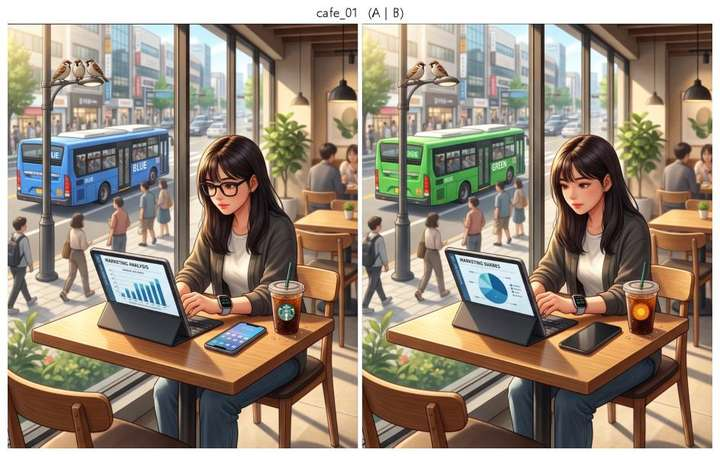

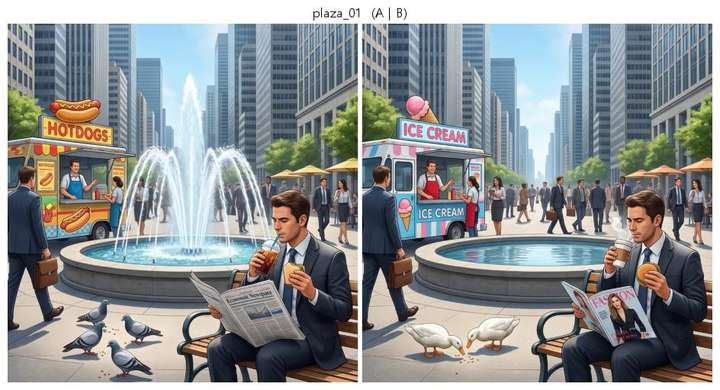

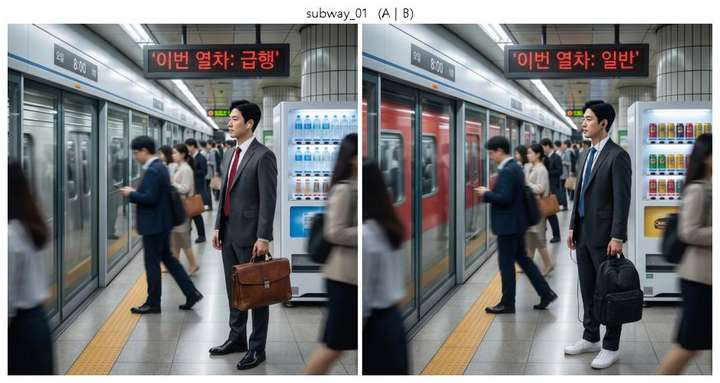

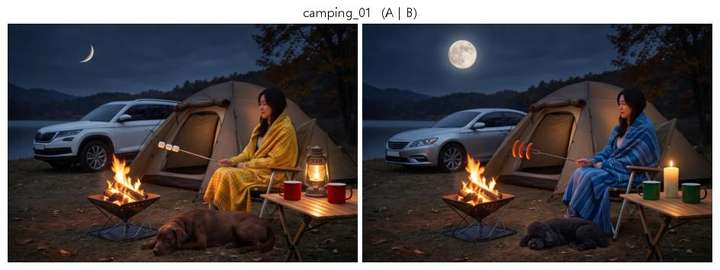

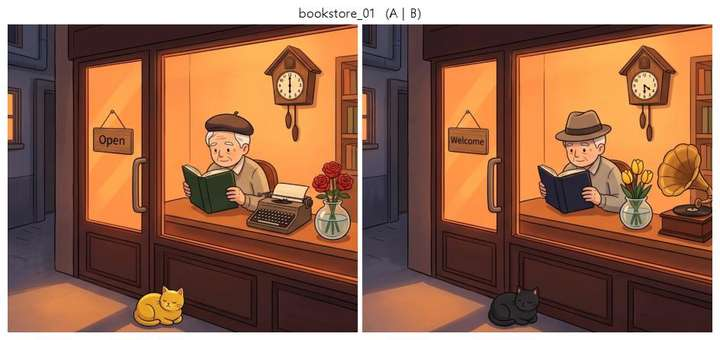

In [2]:
for name in answers:
    A, B = load(name)
    show(side(A, B), f"{name}  (A | B)", w=12)

In [3]:
# 정답 목록
rows = [(name, d["no"], d["what"]) for name, v in answers.items() for d in v]
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(rows, columns=["문제", "번호", "무엇이 바뀌었나"])

,문제,번호,무엇이 바뀌었나
0,cafe_01,1,참새 3마리 → 2마리
1,cafe_01,2,파란 버스 → 초록 버스
2,cafe_01,3,안경 사라짐
3,cafe_01,4,태블릿 화면 막대그래프 → 원그래프
4,cafe_01,5,휴대폰 화면 켜짐 → 꺼짐
5,cafe_01,6,컵 로고
6,plaza_01,1,핫도그 트럭 → 아이스크림 트럭
7,plaza_01,2,앞치마 파랑 → 빨강
8,plaza_01,3,분수 물줄기 사라짐
9,plaza_01,4,비둘기 4마리 → 오리 2마리


대부분이 **같은 자리의 물체가 다른 것으로 바뀐 것**이다(핫도그 트럭 → 아이스크림 트럭, 비둘기 → 오리).
광장 그림의 8번(파라솔 색)은 Gemini가 말하지 않은 차이인데, 아래 탐지기가 찾아내서 정답에 추가했다.

## 3. YOLO가 이 그림을 알아볼까?

선 그림 도안에서는 사전학습 YOLO가 물체를 하나도 찾지 못했다. Gemini 그림은 실제 사진에 가까운 그림이라 다를 것으로 보고,
카페 그림에 작은 모델(YOLO11n)과 큰 모델(YOLO11x)을 돌려 비교했다.

In [4]:
from ultralytics import YOLO

A, B = load("cafe_01")
for weight in ["yolo11n.pt", "yolo11x.pt"]:
    m = YOLO(weight)
    for side_name, img in [("A", A), ("B", B)]:
        r = m.predict(img, conf=0.25, device=0, verbose=False)[0]
        cnt = Counter(r.names[int(c)] for c in r.boxes.cls.tolist())
        print(f"{weight:11s} {side_name}: {dict(cnt.most_common())}")

yolo11n.pt  A: {'person': 11, 'chair': 6, 'car': 3, 'cup': 2, 'cell phone': 2, 'dining table': 2, 'bus': 1, 'laptop': 1, 'potted plant': 1, 'handbag': 1}
yolo11n.pt  B: {'person': 12, 'chair': 7, 'car': 3, 'cup': 2, 'cell phone': 2, 'dining table': 2, 'laptop': 1, 'bus': 1, 'potted plant': 1}
yolo11x.pt  A: {'person': 9, 'chair': 5, 'bird': 3, 'car': 3, 'handbag': 3, 'dining table': 3, 'potted plant': 2, 'laptop': 1, 'bus': 1, 'cell phone': 1, 'cup': 1, 'backpack': 1}
yolo11x.pt  B: {'person': 11, 'chair': 5, 'handbag': 3, 'car': 3, 'potted plant': 2, 'bird': 2, 'dining table': 2, 'laptop': 1, 'bus': 1, 'cup': 1, 'cell phone': 1, 'backpack': 1}


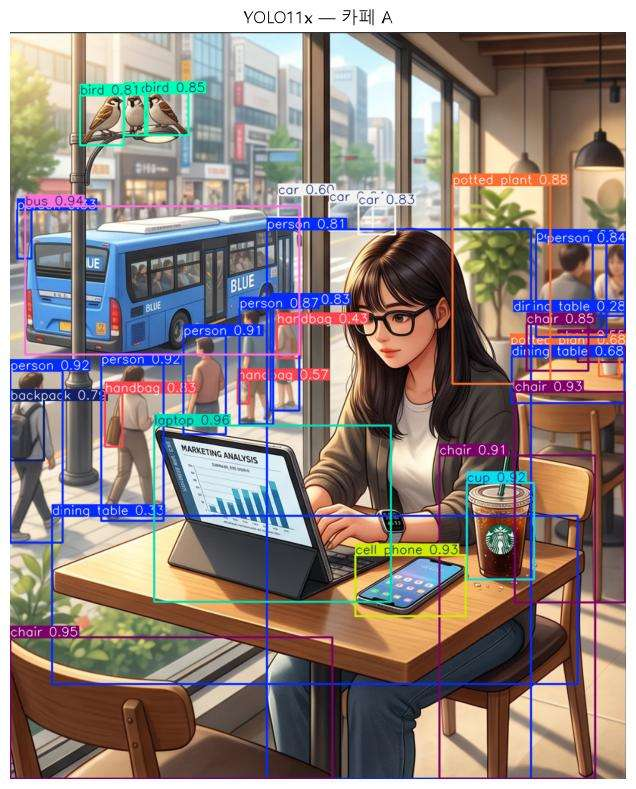

In [5]:
r = YOLO("yolo11x.pt").predict(A, conf=0.25, device=0, verbose=False)[0]
show(r.plot(line_width=2, font_size=12), "YOLO11x — 카페 A", w=8)

물체를 많이 찾는다. 큰 모델(x)은 가로등 위 작은 참새까지 찾아서 **A는 새 3마리, B는 2마리**로 차이가 박스 개수에 그대로 드러난다.
작은 모델(n)은 참새를 못 찾아서, 이후로는 YOLO11x를 쓴다.

하지만 버스 색, 태블릿 화면, 폰 화면처럼 물체는 그대로 있고 **내용만 바뀐 차이**는 A와 B에서 박스가 똑같이 나온다.
그래서 박스를 짝지은 다음, 박스 안의 내용까지 비교하기로 했다.

## 4. 박스 짝짓기

A와 B의 박스 중 위치가 많이 겹치는(IoU ≥ 0.5) 것끼리 짝을 짓는다. 겹침이 큰 쌍부터 차례로 짝을 정한다.

- 짝이 없는 박스: 한쪽에만 있는 물체 (사라짐·추가, 또는 개수가 달라짐)
- 짝이 있는데 클래스가 다름: 다른 물체로 바뀜
- 짝도 있고 클래스도 같음: 내용만 바뀌었을 수 있음

탐지 신뢰도 기준은 0.10으로 낮게 잡았다. 0.25에서는 서점 그림의 고양이와 책이 안 잡혔다. 헛탐지는 다음 단계에서 걸러진다.

In [6]:
finder = dd.Finder()                        # YOLO11x(탐지) + yolo11n-cls
da, db = finder.detect(A), finder.detect(B)
pairs, only_a, only_b = finder.pair(da, db)
print(f"A {len(da)}개, B {len(db)}개 탐지 → 짝 {len(pairs)}쌍, A에만 {len(only_a)}개, B에만 {len(only_b)}개")
print("A에만:", [da[i]["cls"] for i in only_a])
print("B에만:", [db[j]["cls"] for j in only_b])
print("클래스가 다른 짝:", [(da[i]["cls"], db[j]["cls"]) for i, j in pairs if da[i]["cls"] != db[j]["cls"]])

A 47개, B 46개 탐지 → 짝 41쌍, A에만 6개, B에만 5개
A에만: ['bird', 'bird', 'car', 'dining table', 'car', 'person']
B에만: ['bird', 'dining table', 'potted plant', 'person', 'person']
클래스가 다른 짝: []


A에만 있는 bird가 참새 한 마리 차이다. 그런데 A에만/B에만 있는 박스 중에는 사람처럼 **실제로는 양쪽에 다 있는데 YOLO가 한쪽에서만 찾은 것**도 섞여 있다.
박스만 보고 틀린 곳이라고 하면 헛탐지가 많아진다.

## 5. 후보 자리의 내용 비교

짝지은 박스와 한쪽에만 있는 박스를 모두 후보로 보고, **같은 박스 자리를 A와 B에서 똑같이 잘라** 두 조각을 비교한다. 비교하는 값은 두 가지다.

**픽셀 변화 비율**은 두 조각을 겹쳤을 때 색이 크게 달라진 픽셀이 몇 %인지를 나타낸다. 0이면 똑같고, 1이면 전부 바뀐 것이다.
Gemini는 B를 새로 그리면서 선이 몇 픽셀씩 어긋나기 때문에, 두 조각의 위치를 먼저 맞추고 살짝 흐리게 한 다음 비교한다.
같은 자리의 픽셀을 하나하나 비교하므로 **모양이 바뀌거나 물체가 생기고 사라지는 변화**에 강하다.

**색 분포 거리**는 박스 크기가 아니라, 박스 안에 **어떤 색이 얼마나 들어 있는지(색 구성)** 가 얼마나 다른지를 나타낸다.
조각의 픽셀을 색깔별로 세어 "파랑 60%, 회색 25%, 검정 15%" 같은 표(색 히스토그램)를 만들고, A와 B의 표를 비교해 0(같음)~1(완전히 다름)로 나타낸다.
위치는 보지 않고 색의 비율만 보므로 **색이 바뀐 변화**에 강하다.
(색은 HSV로 바꿔 색상 18칸 × 채도 8칸으로 세고, 두 표의 차이는 바타차리야 거리로 계산한다.)

두 값은 서로 부족한 점을 채워 준다. 아래는 이 노트북에서 나온 실제 값이다.

| 바뀐 것 | 픽셀 변화 | 색 분포 거리 | 이유 |
|---|---|---|---|
| 파란 버스 → 초록 버스 | 0.52 | **0.62** | 파랑이 통째로 초록이 되어 색 구성 자체가 바뀜 |
| 참새 3마리 → 2마리 | **0.44~0.53** | 0.11~0.26 | 참새가 있던 자리가 배경이 되어 픽셀은 많이 바뀌지만, 갈색·흰색이라는 색 구성은 비슷함 |
| 흰 SUV → 은색 세단 | **0.40** | 0.17 | 모양이 달라 같은 자리 픽셀은 많이 바뀌지만, 흰색·회색 위주인 것은 그대로 |
| 안 바뀐 물체 | 0~0.2 | 0~0.3 | 둘 다 작음 |

픽셀 변화가 0.25보다 크거나 색 분포 거리가 0.45보다 크면 틀린 곳으로 본다. 처음에는 색 분포 거리만 써서 참새나 자동차처럼 색 구성이 비슷한 변화를 놓쳤고, 픽셀 변화를 더하면서 잡히기 시작했다.

참고로 YOLO 분류 모델의 특징 벡터 거리(아래 표의 '모양')로도 판단해 보려 했지만, 거의 모든 후보가 0.0~0.2로 나와 차이를 구분하지 못해서 판단에는 쓰지 않았다.

In [7]:
found, cands, _, _ = finder.find(A, B)
df = pd.DataFrame([dict(후보=c["why"], 물체=c["label"], 픽셀변화=round(c["pix"], 3), 색분포=round(c["color"], 3),
                        모양=round(c["shape"], 3), 틀린곳=c["diff"],
                        정답=[g["no"] for g in answers["cafe_01"] if dd.hits(c["box"], g)]) for c in cands])
df.sort_values("픽셀변화", ascending=False).head(12)

,후보,물체,픽셀변화,색분포,모양,틀린곳,정답
47,B에만 있음,bird,0.531,0.210,0.068,True,[1]
17,내용 비교,bus,0.524,0.618,0.019,True,[2]
41,A에만 있음,bird,0.500,0.263,0.047,True,[1]
46,A에만 있음,person,0.440,0.213,0.041,True,[2]
42,A에만 있음,bird,0.438,0.171,0.054,True,[1]
28,내용 비교,bird,0.436,0.110,0.017,True,[1]
50,B에만 있음,person,0.426,0.406,0.026,True,[2]
9,내용 비교,cell phone,0.413,0.498,0.096,True,[5]
51,B에만 있음,person,0.256,0.339,0.032,True,[2]
2,내용 비교,cup,0.134,0.244,0.019,False,[6]


버스, 휴대폰, 참새는 픽셀 변화가 0.4 이상으로 크게 나온다. 한쪽에서만 잡힌 사람 중 일부도 높게 나왔는데, 버스 바로 앞에 서 있어서
뒤에 보이는 버스 색이 바뀐 것까지 같이 잡힌 경우다(정답 2번 자리). 모양 거리는 버스(0.02)처럼 색만 바뀐 경우를 전혀 구분하지 못한다.

아래는 한쪽에서만 잡힌 후보만 모은 것이다. 참새와 버스 앞 사람을 빼면 픽셀 변화가 작아서 걸러진다.
YOLO가 한쪽에서만 놓친 물체가 이 단계에서 정리된다.

In [8]:
df[df["후보"] != "내용 비교"].sort_values("픽셀변화", ascending=False)

,후보,물체,픽셀변화,색분포,모양,틀린곳,정답
47,B에만 있음,bird,0.531,0.210,0.068,True,[1]
41,A에만 있음,bird,0.500,0.263,0.047,True,[1]
46,A에만 있음,person,0.440,0.213,0.041,True,[2]
42,A에만 있음,bird,0.438,0.171,0.054,True,[1]
50,B에만 있음,person,0.426,0.406,0.026,True,[2]
51,B에만 있음,person,0.256,0.339,0.032,True,[2]
43,A에만 있음,car,0.000,0.139,0.000,False,[]
44,A에만 있음,dining table,0.000,0.146,0.000,False,[]
45,A에만 있음,car,0.000,0.163,0.000,False,[]
48,B에만 있음,dining table,0.000,0.164,0.001,False,[]


## 6. 한 문제 풀어 보기

틀린 곳 중 같은 종류가 붙어 있으면 하나로 묶고(자판기 병 12개 → 1묶음), 겹치면 더 구체적인 작은 박스만 남긴다.
그림에서 빨간 박스는 탐지기가 찾은 곳, 초록 박스는 찾은 정답, 노란 박스는 놓친 정답이다.

cafe_01 → ['person', 'bird', 'cell phone']


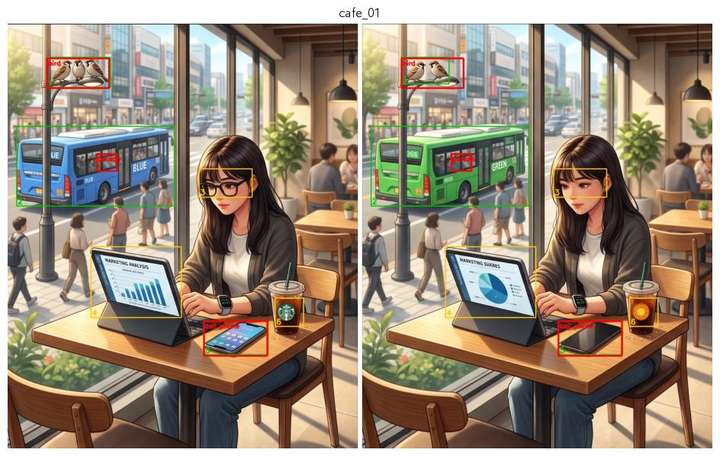

subway_01 → ['cell phone', 'tie', 'bottle', 'handbag']


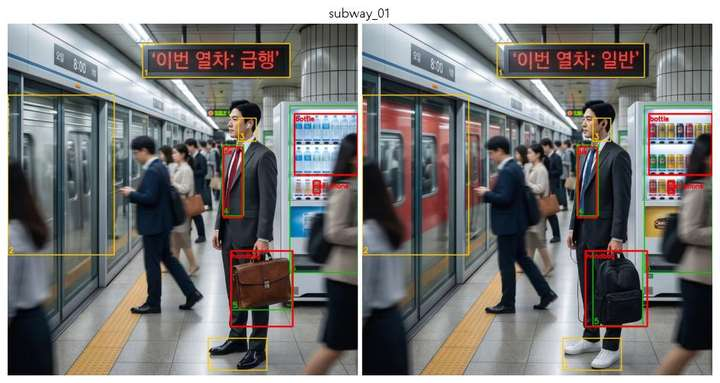

In [9]:
from pathlib import Path
out = Path("results_ai"); out.mkdir(exist_ok=True)
for name in ["cafe_01", "subway_01"]:
    A, B = load(name)
    found, *_ = finder.find(A, B)
    dd.draw(A, B, found, answers[name], out / f"{name}.jpg")
    print(name, "→", [f["label"] for f in found])
    show(cv2.imread(str(out / f"{name}.jpg")), name, w=12)

## 7. 5문제 채점

탐지 박스가 정답 박스와 겹치거나(IoU ≥ 0.1) 정답 영역 안의 일부를 가리키면 찾은 것으로 본다.
처음에는 IoU만 봤는데, 트럭 위 핫도그 장식처럼 정답의 **일부**를 정확히 가리켜도 겹치는 비율이 작아 오답이 되어서 규칙을 고쳤다.

- **재현율**: 정답 중 찾은 비율
- **정밀도**: 탐지한 것 중 정답 자리인 비율

In [10]:
rows, all_cands = [], []
for name, gts in answers.items():
    A, B = load(name)
    found, cands, *_ = finder.find(A, B)
    dd.draw(A, B, found, gts, out / f"{name}.jpg")
    all_cands += [(c["pix"], c["color"], any(dd.hits(c["box"], g) for g in gts)) for c in cands]
    rows.append(dict(문제=name, 정답=len(gts),
                     찾음=sum(any(dd.hits(f["box"], g) for f in found) for g in gts),
                     탐지=len(found),
                     맞음=sum(any(dd.hits(f["box"], g) for g in gts) for f in found),
                     놓친것=", ".join(g["what"] for g in gts if not any(dd.hits(f["box"], g) for f in found))))
score = pd.DataFrame(rows)
tot = score[["정답", "찾음", "탐지", "맞음"]].sum()
print(f"재현율 {tot['찾음'] / tot['정답']:.1%} ({tot['찾음']}/{tot['정답']}),  정밀도 {tot['맞음'] / tot['탐지']:.1%} ({tot['맞음']}/{tot['탐지']})")
score

재현율 65.7% (23/35),  정밀도 100.0% (26/26)


,문제,정답,찾음,탐지,맞음,놓친것
0,cafe_01,6,3,3,3,"안경 사라짐, 태블릿 화면 막대그래프 → 원그래프, 컵 로고"
1,plaza_01,8,8,11,11,
2,subway_01,7,3,4,4,"전광판 급행 → 일반, 은색 열차 → 빨간 열차, 무선 이어폰 → 유선 이어폰, 검은 구두 → 흰 운동화"
3,camping_01,7,5,4,4,"초승달 → 보름달, 마시멜로 → 소시지"
4,bookstore_01,7,4,4,4,"Open → Welcome 팻말, 베레모 → 중절모, 시계 바늘"


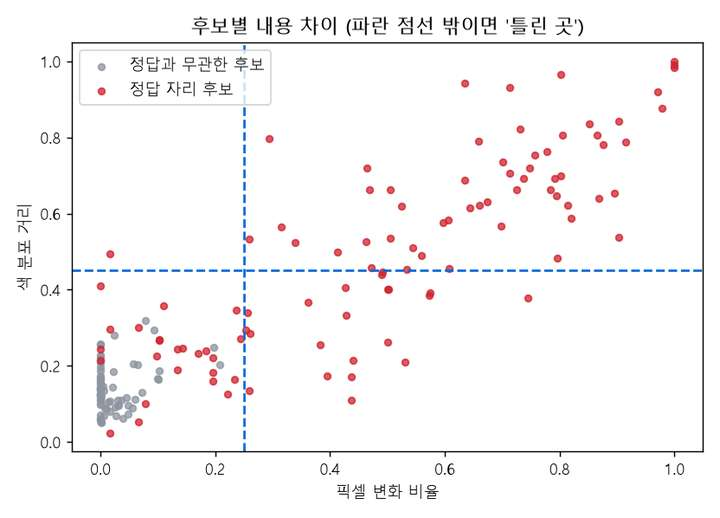

In [11]:
dd.plot(all_cands, out / "threshold.png")
display(Image(filename=str(out / "threshold.png"), width=560))

이 그래프는 탐지기가 "틀린 곳"을 어떤 기준으로 가르는지 보여 준다. 점 하나가 후보 하나(YOLO가 찾은 박스 하나)이고, 5문제에서 나온 후보를 전부 찍었다.
가로축은 픽셀 변화 비율, 세로축은 색 분포 거리다. 회색은 정답과 상관없는 자리(원래 안 바뀐 물체), 빨강은 정답 자리와 겹치는 후보다.
파란 점선이 판정 기준으로, **세로선(0.25)의 오른쪽이거나 가로선(0.45)의 위쪽이면 "틀린 곳"**, 왼쪽 아래 칸에 있으면 "같다"로 판정한다.

- **회색은 전부 왼쪽 아래에 있다.** 안 바뀐 물체를 틀렸다고 잘못 짚은 경우가 없다는 뜻이고, 그래서 정밀도가 100%다.
- **빨강은 대부분 오른쪽에 있다.** 바뀐 물체는 픽셀 변화가 크게 나와 잘 잡혔다. 맨 오른쪽 위(1.0, 1.0)는 핫도그 장식 → 아이스크림, 생수 → 캔처럼 통째로 바뀐 것이다.
- **세로선이 가로선보다 중요하다.** 빨강 중에는 색 분포 거리는 0.1~0.4로 낮은데 픽셀 변화는 0.3~0.8로 큰 점이 많다. 가로선(색 분포)만 썼다면 모두 놓쳤을 것이다.
- **왼쪽 아래에도 빨강이 있다.** 하나는 진짜 놓친 것(태블릿 화면, 컵 로고, 시계 바늘, 열차 색)으로, 물체는 잡혔지만 바뀐 부분이 박스에 비해 작아 비율이 낮게 나왔다. 다른 하나는 버스 옆 사람, 머그잔 아래 식탁처럼 정답 영역과 겹치기만 하고 자기는 안 바뀐 후보로, 같은 정답을 다른 후보가 이미 잡아서 문제가 되지 않는다.

다만 회색 중 가장 오른쪽 점이 0.21쯤으로 기준선 0.25와 가깝고, 기준선을 이 5문제를 보며 정했다. 새 문제에서는 회색이 선을 넘어 헛탐지가 생길 수 있다.

**시행착오에 따른 점수 변화**

| 단계 | 바꾼 것 | 재현율 | 정밀도 |
|---|---|---|---|
| 1 | 박스 비교 + 색 분포 비교 | 32.4% | 34.2% |
| 2 | 채점 규칙 수정, 탐지 신뢰도 0.25 → 0.10 | 50.0% | 95.5% |
| 3 | 픽셀 변화 비교 추가, 같은 종류 묶기 | 65.7% | 100% |

3단계에서 탐지기가 찾은 파라솔 색 차이를 정답에 추가했다(34 → 35개). 파라솔을 빼고 원래 34개로 세면 재현율 64.7%, 정밀도 96.2%다.

## 8. 놓친 것과 한계

**놓친 12개**는 두 종류다.

- **YOLO가 모르는 물체 (8개)**: 안경, 전광판, 이어폰, 구두, 달, 마시멜로, 문 팻말, 모자.
  YOLO가 배운 80가지 물체(COCO)에 없어서 박스가 안 생기고, 박스가 없으면 비교할 후보도 없다.
- **찾았지만 차이가 작게 나옴 (4개)**: 태블릿 화면, 컵 로고, 시계 바늘, 열차 색.
  물체 박스는 잡혔지만 바뀐 부분이 박스에 비해 작거나 흐려서 기준을 넘지 못했다.

**한계**

- 기준값(픽셀 변화 0.25, 색 분포 0.45)을 같은 5문제를 보며 정했다. 새 문제에서도 맞는지는 문제를 더 만들어 확인해야 한다.
- 분수처럼 정답 영역이 큰 경우, 그 안에서 바뀐 뒤쪽 사람들을 가리켜도 맞음으로 셌다. 채점이 조금 너그럽다.
- 정밀도 100%는 5문제에서 헛탐지가 없었다는 뜻이다. 문제가 늘면 떨어질 수 있다.

YOLO가 찾은 물체 안에서만 차이를 볼 수 있다는 게 이 방법의 가장 큰 한계다.
YOLO가 모르는 물체(모자, 안경, 팻말)를 찾으려면 그런 물체까지 배운 모델이 필요하다.

# 개인 회고


### 진행하면서 막혔던 부분과 해결

**1부 실습**

| 막힌 부분 | 원인 | 해결 |
|---|---|---|
| Roboflow 링크로 받은 데이터가 이미지 3장뿐 | 공유 링크가 다른 버전(v2, `stamp` 1개 클래스)이었다 | 데이터셋 버전 8개의 분할 수를 비교해, 과제와 같은 **v10**(train 1,100 / valid 273 / test 193)을 찾아 다시 받았다 |
| 명령줄로 받은 zip이 HTML 파일 | `universe.roboflow.com` 링크가 보안 확인 페이지를 돌려줬다 | Roboflow 안내 형식인 `app.roboflow.com/ds/...` 주소로 받았다 |
| RTX 5060에 맞는 PyTorch 필요 | RTX 50 시리즈는 CUDA 12.8 빌드가 필요하다 | `--index-url .../cu128`로 PyTorch를 설치했다 |
| 과제 코드 `import requests=` 오류 | 문법 오류(오타) | `import requests`로 고쳤다 |
| 과제의 `./runs/detect/predict/bus.jpg`를 못 찾음 | 결과가 홈 폴더(`C:\Users\...\runs`)에 저장되고 있었다 | 이 프로젝트 커널에만 YOLO 설정 폴더를 따로 지정해, 결과가 노트북 폴더의 `runs/`에 저장되게 했다 |
| `data.yaml`의 `../train/images` 상대경로 | 실행 위치에 따라 경로가 달라진다 | 데이터셋을 과제와 같은 `../datasets/stamp` 위치에 두었다 |
| PDF에 숫자 수천 개가 수십 쪽 찍힘 | `model.train()` 반환값과 `print(metrics)`가 곡선 데이터까지 모두 출력했다 | 노트북은 과제 코드 그대로 두고, PDF로 바꿀 때 긴 출력은 앞뒤만 남기게 했다 |
| 다시 학습하니 결과 숫자가 달라짐 | GPU 학습은 시드를 고정해도 실행마다 조금씩 달라진다 (mAP50-95 ±0.01) | 해석을 최종 실행 결과에 맞춰 다시 썼다 |
| 노트북 결과가 덮어써질 뻔함 | 실행 전 버전이 열린 JupyterLab 탭이 자동 저장했다 | 백그라운드 실행 중에는 Jupyter 서버를 종료해 같은 노트북이 열려 있지 않게 했다 |

**2부 틀린그림찾기**

| 막힌 부분 | 원인 | 해결 |
|---|---|---|
| 인터넷 틀린그림 도안에서 YOLO가 물체를 하나도 못 찾음 | 사전학습 YOLO는 실제 사진으로 배운 모델이라 흑백 선 그림을 물체로 보지 못한다 | YOLO가 알아볼 수 있는 실사에 가까운 그림으로 데이터를 바꿨다 |
| 사진을 직접 편집해 만든 데이터가 부자연스러움 | 지운 자리가 뭉개지고, 색을 바꾸면 사람이 초록색이 되는 등 편집한 티가 났다 | Gemini로 틀린그림찾기 그림을 통째로 생성했다 |
| Gemini 그림에 제목·설명 글자가 같이 들어 있음 | 그림 위아래에 제목, 판 이름, 설명 문구가 붙어 나온다 | 그림 부분만 자동으로 잘라내는 스크립트(`prepare_pairs.py`)를 만들었다 |
| Gemini가 적은 차이 개수와 실제가 다름 | 카페는 7군데라고 했지만 6개만 있었고, 광장에는 말하지 않은 차이(파라솔 색)가 있었다 | 정답표를 그림을 보며 직접 확인하고 고쳤다 |
| 박스만 비교하니 색·화면만 바뀐 차이를 못 찾음 | 버스 색, 폰 화면처럼 물체는 그대로라 A와 B의 박스가 똑같이 나온다 | 박스 자리를 잘라 내용(픽셀 변화, 색 분포)까지 비교했다 |
| 맞게 가리켰는데 오답으로 채점됨 | 트럭 위 장식처럼 정답의 일부만 가리키면 IoU가 작다 | 정답 영역 안을 가리키면 인정하도록 채점 규칙을 고쳤다 |
| YOLO 분류 모델 특징 벡터로는 차이 구분이 안 됨 | 거의 모든 후보가 0.0~0.2로 나왔다 | 조각을 맞춘 뒤 색이 바뀐 픽셀 비율을 쓰니 잘 갈렸다 |


### 실습 전체 정리

✍️ [알게 된 것]
YOLO 모델 학습부터 결과 검증, 그리고 추론 결과를 통해 객체의 클래스, 신뢰도, 위치 좌표를 확인하는 기본 흐름을 파악했다.

✍️ [어려웠던 것]
Results 객체나 Boxes 텐서 출력값처럼 생소한 복잡한 수치들이 한꺼번에 나와 헷갈렸고, Precision, Recall, mAP 같은 비슷한 성능 지표들의 개념을 구분하고 해석하는 과정이 다소 어려웠다.

✍️ [더 해보고 싶은 것]
이번에 배운 기초를 활용해 객체를 찾아내고 좌표를 비교하는 원리를 응용해서, 두 화면의 다른 점을 순식간에 찾아내는 초고속 틀린그림찾기 게임핵(매크로)을 만들어보고 싶다.


### KPT
- **Keep**
  - **AI를 활용해 실습을 진행한 것.** 막히는 부분이 있어도 AI에게 원인을 묻고 고치게 하니 바로바로 해결돼서 실습 진행에 어려움이 없었다. 다음에도 이 방식으로 진행할 것 같다.
  - **YOLO의 기본 조작을 이해했다.** 신뢰도를 조절하는 방법, 결과물(클래스 번호, xywh·xyxy 좌표)을 해석하는 방법을 직접 해보며 익혔다.
  - **신뢰도는 목적에 맞게 쓰는 손잡이라는 것을 알았다.** 신뢰도를 바꿔 가며 박스가 몇 개 생기는지 확인해 보니, 오탐 비용이 큰 작업에서는 신뢰도를 높이고, 하나라도 발견하는 것이 중요한 작업에서는 신뢰도를 낮춰서 목적에 맞게 쓰면 된다.
- **Problem**
  - **처음에는 원리를 이해하는 데 매달렸다.** 수업을 진행하다 보니 원리보다 **사용 방법과 어디에 쓰는지**를 아는 것이 더 중요하다는 것을 깨달았다. 그래서 AI를 활용해 "내가 정한 가상의 목적에 맞게 작동하는 모델을 만들려면 어떻게 해야 하는가"를 생각해 보는 방식으로 바꿨다.
    - 예: 제조업에서는 목표 정확도를 얼마로 잡아야 할까? → 잘못 판정하면 비용이 크니 **정확도 90% 이상**, 또는 논문을 참고해 **사람 검사자와 같거나 그 이상**을 목표로 하는 것이 좋겠다. 이 기준으로 보면 이번 모델은 도장은 거의 다 찾지만(검증 재현율 1.000), 신발은 가장자리·손에 든 신발을 자주 놓쳐 아직 부족하다.
  - **큰 모델·최신 모델은 확신도가 높아졌다**(개인 실험 1: 평균 확신도 v8n 0.66 → v8s·11n 0.84). 그래서 될 수 있으면 **최신 모델을 쓰고 신뢰도를 올리는 것**이 더 좋겠다고 생각했다.
- **Try**
  - **YOLO로 틀린그림 찾기 도구를 만들어 보고 싶다.** 두 그림에서 다른 곳에 박스를 치는 것은, 정상 제품과 다른 부분을 찾아내는 **불량 영역 탐지**와 원리가 같다. 재미있는 주제로 먼저 해보고, 직접 찍은 제품 사진의 정상/불량 탐지로 이어가 볼 생각이다.


### AAR (After Action Review)
| 질문 | 답 |
|---|---|
| 원래 의도한 것은? | 솔직히 큰 기대 없이 시작했다. |
| 실제로 일어난 일은? | "목적에 따라 어디에 쓸 수 있는지 공부하라"는 안내대로 해보니, 틀린그림 찾기 도구 같은 나름 재미있는 발상까지 이어졌고 과제가 재미있어졌다. |
| 무엇을 얻었나? | ① YOLO 기본 사용법과 목적에 맞게 쓰는 방법 ② 기존 공부 방법에 더해, **문제를 파악하고 해결하기 위해 공부하는 방법** |
| 현장에 쓴다면 먼저 보완할 점은? | ① **가장자리와 손에 든 신발을 놓치는 문제**부터 해결해야 한다. ② 하드웨어로는 **일정 시간마다 렌즈를 닦아 주는 장치**를 달아 먼지로 생기는 흐림을 막고, 노이즈는 주로 어두운 조명에서 생기므로 **조명을 보강**한다. |


### 동료 피드백 (선택)
- 받은 피드백 없음